# Домашнее задание №5–6. Baseline, метрики и улучшенные модели

## Проект: Hotel Booking Cancellation Risk

**Цель ноутбука:** построить воспроизводимое baseline-решение для прогноза отмен гостиничных бронирований, сравнить простые и усложненные модели, оценить качество не только через ML-метрики, но и через продуктовый сценарий revenue-менеджера.

Ключевая правка относительно предыдущей версии: теперь в ноутбуке разделены две сущности:

```text
risk_score = вероятность отмены бронирования
business_priority_score = приоритет внимания менеджера с учетом денег, типа депозита и применимого действия
```

Это важно, потому что `Non Refund` может иметь высокий риск отмены как ML-событие, но низкий финансовый риск для отеля. Поэтому top-list для менеджера сортируется не только по вероятности отмены, а по ожидаемой потере выручки с учетом условий депозита.

## Карта соответствия заданию

| Требование ДЗ №5–6 | Где закрыто в ноутбуке |
|---|---|
| Загрузка и очистка данных | Разделы 1–3 |
| Анализ данных | Раздел 4 с графиками и выводами |
| 1–2 простые модели | Rule-based baseline, Logistic Regression, Random Forest |
| Усложненные модели | LightGBM Random Search, XGBoost Random Search, Tabular + Text TF-IDF |
| Оптимизация гиперпараметров / AutoML | Random search по LightGBM и XGBoost + единый leaderboard |
| Мультимодальность / сериализация | Табличные признаки + текстовое представление бронирования через TF-IDF |
| 2+ ML-метрики | ROC-AUC, PR-AUC, Brier, Precision, Recall, F1, Precision@K, Recall@K, Lift@K |
| Совокупная метрика качества | `quality_index` |
| Анализ результатов | Финальные разделы с выбором модели и продуктовой интерпретацией |

## 0. Импорты и настройки

Флаг `RUN_LONG_EXPERIMENTS=True` оставлен включенным: ноутбук рассчитан на полный запуск, а не на демонстрационный черновик. Если нужно быстро проверить пайплайн, можно временно поставить `False`, но для сдачи лучше прогнать полностью и сохранить outputs.

In [26]:
import os
import time
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, loguniform, uniform

from sklearn.model_selection import ParameterSampler
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RUN_LONG_EXPERIMENTS = True
N_ITER_LGBM = 8
N_ITER_XGB = 6
N_ITER_MULTIMODAL = 5

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    # если ноутбук запущен из папки notebooks/
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "hotel_bookings.csv"
FIG_DIR = ROOT / "reports" / "figures" / "hw56_advanced"
TABLE_DIR = ROOT / "reports" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)

ROOT: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk
DATA_PATH: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/data/raw/hotel_bookings.csv


## 1. Загрузка данных

Используется основной датасет Hotel Booking Demand Dataset. Одна строка — одно бронирование. Целевая переменная `is_canceled`: 1 — бронь отменена, 0 — бронь не отменена.

In [27]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head())
display(pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "missing": df_raw.isna().sum().values,
    "missing_share": (df_raw.isna().mean().values).round(4),
}))

(119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,column,dtype,missing,missing_share
0,hotel,str,0,0.0000
1,is_canceled,int64,0,0.0000
2,lead_time,int64,0,0.0000
3,arrival_date_year,int64,0,0.0000
4,arrival_date_month,str,0,0.0000
5,arrival_date_week_number,int64,0,0.0000
6,arrival_date_day_of_month,int64,0,0.0000
7,stays_in_weekend_nights,int64,0,0.0000
8,stays_in_week_nights,int64,0,0.0000
9,adults,int64,0,0.0000


## 2. Leakage audit и момент прогноза

Модель должна работать **после создания бронирования, но до факта отмены и до финального статуса**. Поэтому признаки, которые становятся известны постфактум, исключаются. Это ключевой контроль качества baseline: иначе ML-метрики будут завышены, но продукт не сможет работать на будущих бронированиях.

In [28]:
LEAKAGE_COLUMNS = [
    "reservation_status",
    "reservation_status_date",
]

CONSERVATIVE_EXCLUDE_COLUMNS = [
    "assigned_room_type",  # может назначаться позже, после создания брони
    "booking_changes",     # может изменяться после первичного бронирования
]

HIGH_CARDINALITY_OPERATIONAL_IDS = [
    "agent",   # анонимизированный ID агента; может плохо переноситься на новый отель
    "company", # анонимизированный ID компании; много пропусков и слабая переносимость
]

leakage_report = []
for col in LEAKAGE_COLUMNS + CONSERVATIVE_EXCLUDE_COLUMNS + HIGH_CARDINALITY_OPERATIONAL_IDS:
    leakage_report.append({
        "column": col,
        "nunique": df_raw[col].nunique(dropna=False) if col in df_raw.columns else None,
        "missing_share": df_raw[col].isna().mean() if col in df_raw.columns else None,
        "decision": "exclude",
        "reason": (
            "direct post-factum leakage" if col in LEAKAGE_COLUMNS else
            "not guaranteed at prediction moment" if col in CONSERVATIVE_EXCLUDE_COLUMNS else
            "high-cardinality anonymized operational id; weak transferability"
        )
    })

leakage_report = pd.DataFrame(leakage_report)
display(leakage_report)
leakage_report.to_csv(TABLE_DIR / "hw56_leakage_audit.csv", index=False)

# Демонстрация, почему reservation_status нельзя использовать.
if "reservation_status" in df_raw.columns:
    display(pd.crosstab(df_raw["reservation_status"], df_raw["is_canceled"], normalize="index").round(3))

,column,nunique,missing_share,decision,reason
0,reservation_status,3,0.000000,exclude,direct post-factum leakage
1,reservation_status_date,926,0.000000,exclude,direct post-factum leakage
2,assigned_room_type,12,0.000000,exclude,not guaranteed at prediction moment
3,booking_changes,21,0.000000,exclude,not guaranteed at prediction moment
4,agent,334,0.136862,exclude,high-cardinality anonymized operational id; we...
5,company,353,0.943069,exclude,high-cardinality anonymized operational id; we...


is_canceled,0,1
reservation_status,,
Canceled,0.0,1.0
Check-Out,1.0,0.0
No-Show,0.0,1.0


## 3. Очистка и feature engineering

Здесь создаются признаки, которые имеют бизнес-смысл для revenue-менеджера: длительность проживания, стоимость бронирования, наличие детей, спецзапросы, история отмен, сезонность и интервалы `lead_time`.

In [29]:
def prepare_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Базовые пропуски.
    df["children"] = df["children"].fillna(0)
    df["country"] = df["country"].fillna("Unknown")
    for col in ["agent", "company"]:
        if col in df.columns:
            df[col] = df[col].fillna("missing").astype(str)

    # Невалидные строки для моделирования.
    df = df[(df[["adults", "children", "babies"]].sum(axis=1) > 0)].copy()
    df = df[df["adr"] >= 0].copy()

    month_order = [
        "January", "February", "March", "April", "May", "June",
        "July", "August", "September", "October", "November", "December"
    ]
    month_map = {m: i + 1 for i, m in enumerate(month_order)}
    df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
    df["arrival_date"] = pd.to_datetime(
        dict(
            year=df["arrival_date_year"],
            month=df["arrival_month_num"],
            day=df["arrival_date_day_of_month"],
        ),
        errors="coerce",
    )

    df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
    df["total_guests"] = df["adults"] + df["children"] + df["babies"]
    df["has_children"] = ((df["children"] + df["babies"]) > 0).astype(int)
    df["has_previous_cancellations"] = (df["previous_cancellations"] > 0).astype(int)
    df["has_special_requests"] = (df["total_of_special_requests"] > 0).astype(int)
    df["has_parking_request"] = (df["required_car_parking_spaces"] > 0).astype(int)
    df["booking_value"] = (df["adr"] * df["total_nights"]).clip(lower=0)

    df["lead_time_bin"] = pd.cut(
        df["lead_time"],
        bins=[-1, 7, 30, 90, 180, 365, 10_000],
        labels=["0-7", "8-30", "31-90", "91-180", "181-365", "365+"],
    ).astype(str)

    df["nights_bin"] = pd.cut(
        df["total_nights"],
        bins=[-1, 1, 3, 7, 14, 1_000],
        labels=["0-1", "2-3", "4-7", "8-14", "15+"],
    ).astype(str)

    df["adr_bin"] = pd.qcut(
        df["adr"].rank(method="first"),
        q=5,
        labels=["adr_q1", "adr_q2", "adr_q3", "adr_q4", "adr_q5"],
    ).astype(str)

    # Сериализация табличных признаков в текст для мультимодального / text+tabular baseline.
    df["booking_text"] = (
        "hotel " + df["hotel"].astype(str) +
        " market " + df["market_segment"].astype(str) +
        " channel " + df["distribution_channel"].astype(str) +
        " deposit " + df["deposit_type"].astype(str) +
        " customer " + df["customer_type"].astype(str) +
        " room " + df["reserved_room_type"].astype(str) +
        " lead " + df["lead_time_bin"].astype(str) +
        " nights " + df["nights_bin"].astype(str) +
        " adr " + df["adr_bin"].astype(str) +
        " special_requests " + df["total_of_special_requests"].astype(str) +
        " repeated_guest " + df["is_repeated_guest"].astype(str)
    )
    return df

model_df = prepare_dataframe(df_raw)
model_df = model_df.dropna(subset=["arrival_date"]).sort_values("arrival_date").reset_index(drop=True)

print(model_df.shape)
display(model_df[["arrival_date", "hotel", "is_canceled", "lead_time", "deposit_type", "booking_value", "booking_text"]].head())

(119209, 45)


,arrival_date,hotel,is_canceled,lead_time,deposit_type,booking_value,booking_text
0,2015-07-01,Resort Hotel,0,342,No Deposit,0.0,hotel Resort Hotel market Direct channel Direc...
1,2015-07-01,City Hotel,0,257,No Deposit,160.0,hotel City Hotel market Offline TA/TO channel ...
2,2015-07-01,City Hotel,0,257,No Deposit,203.0,hotel City Hotel market Offline TA/TO channel ...
3,2015-07-01,City Hotel,0,257,No Deposit,203.0,hotel City Hotel market Offline TA/TO channel ...
4,2015-07-01,City Hotel,0,257,No Deposit,203.0,hotel City Hotel market Offline TA/TO channel ...


## 4. EDA с выводами для моделирования

В этом блоке проверяется фактура: баланс классов, отмены по сегментам, депозитам, lead time и денежному масштабу. Эти графики нужны, чтобы метрики и baseline не выглядели произвольными.

saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/target_distribution.png


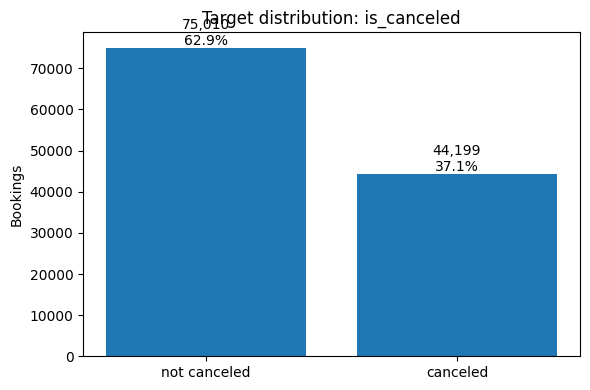

,count,mean
hotel,,
City Hotel,79163,41.8%
Resort Hotel,40046,27.8%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/cancel_rate_by_hotel.png


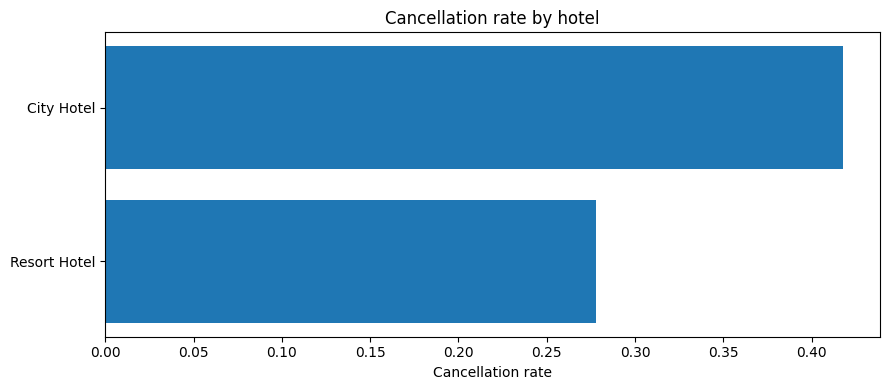

,count,mean
deposit_type,,
Non Refund,14587,99.4%
No Deposit,104460,28.4%
Refundable,162,22.2%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/cancel_rate_by_deposit_type.png


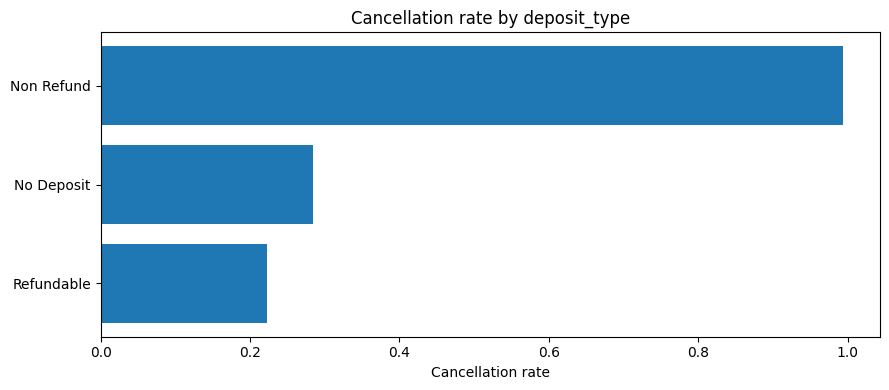

,count,mean
market_segment,,
Undefined,2,100.0%
Groups,19790,61.1%
Online TA,56408,36.8%
Offline TA/TO,24182,34.3%
Aviation,235,22.1%
Corporate,5282,18.8%
Direct,12582,15.4%
Complementary,728,12.2%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/cancel_rate_by_market_segment.png


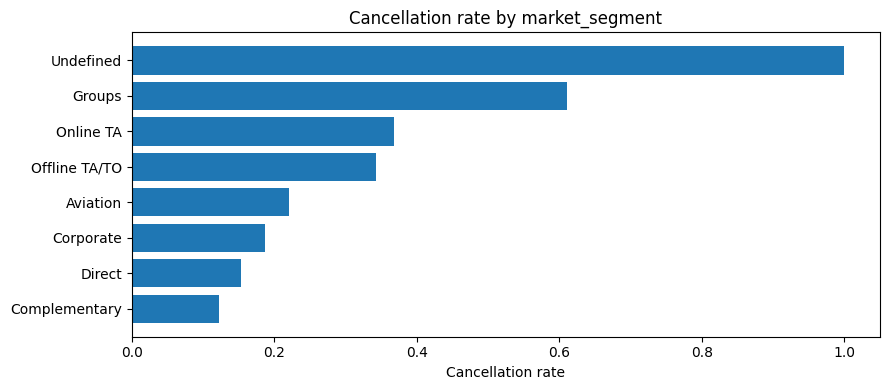

,count,mean
customer_type,,
Transient,89476,40.8%
Contract,4072,31.0%
Transient-Party,25087,25.5%
Group,574,10.1%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/cancel_rate_by_customer_type.png


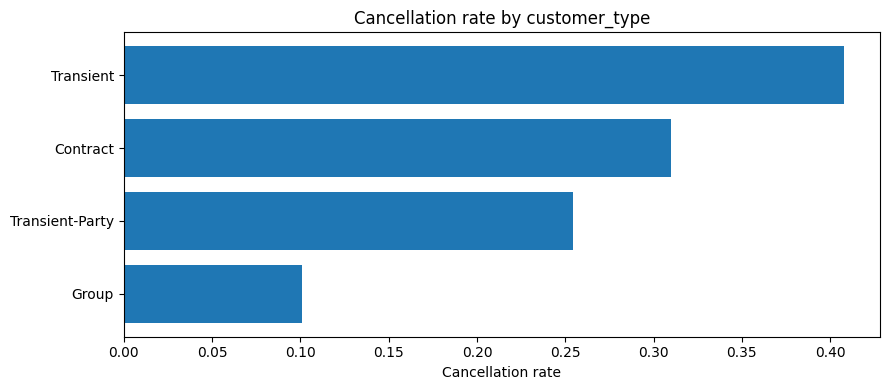

,count,mean
lead_time_bin,,
365+,3147,67.7%
181-365,21533,55.5%
91-180,26420,44.7%
31-90,29529,37.7%
8-30,18945,27.9%
0-7,19635,9.6%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/cancel_rate_by_lead_time_bin.png


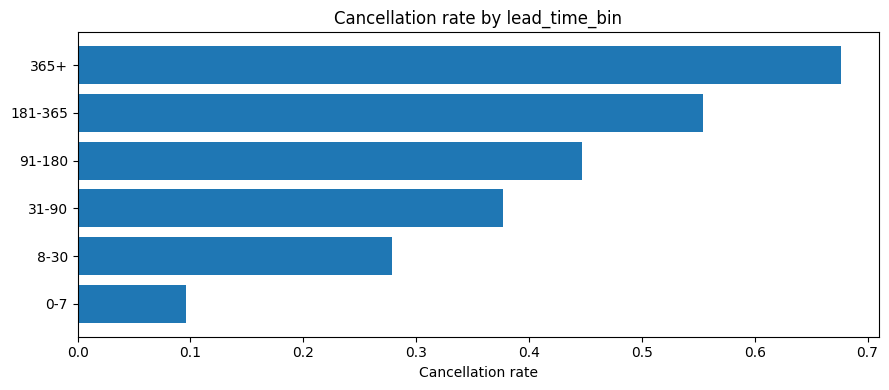

,count,mean
total_of_special_requests,,
0,70200,47.8%
2,12952,22.1%
1,33183,22.0%
3,2494,17.8%
4,340,10.6%
5,40,5.0%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/cancel_rate_by_total_of_special_requests.png


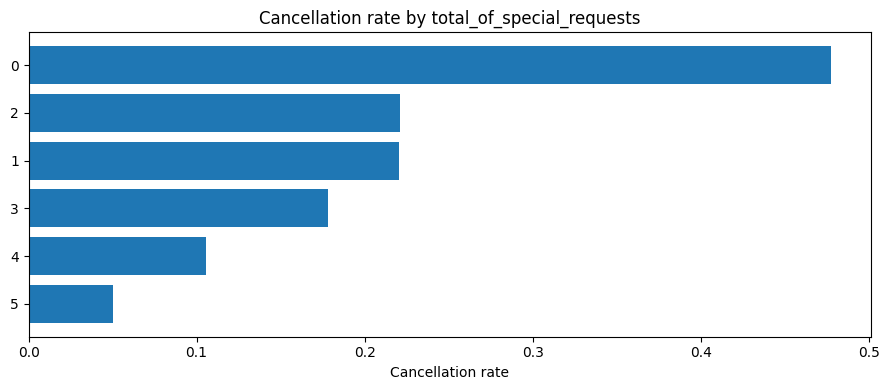

In [30]:
def save_current_fig(name: str):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)

# 4.1 Target distribution
fig, ax = plt.subplots(figsize=(6, 4))
vc = model_df["is_canceled"].value_counts().sort_index()
ax.bar(["not canceled", "canceled"], vc.values)
ax.set_title("Target distribution: is_canceled")
ax.set_ylabel("Bookings")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}\n{v / len(model_df):.1%}", ha="center", va="bottom")
save_current_fig("target_distribution.png")
plt.show()

# 4.2 Cancellation rate by key categorical features
for col in ["hotel", "deposit_type", "market_segment", "customer_type", "lead_time_bin", "total_of_special_requests"]:
    tmp = model_df.groupby(col, observed=False)["is_canceled"].agg(["count", "mean"]).sort_values("mean", ascending=False)
    display(tmp.head(20).style.format({"mean": "{:.1%}"}))
    fig, ax = plt.subplots(figsize=(9, 4))
    tmp_plot = tmp.sort_values("mean", ascending=True).tail(15)
    ax.barh(tmp_plot.index.astype(str), tmp_plot["mean"].values)
    ax.set_title(f"Cancellation rate by {col}")
    ax.set_xlabel("Cancellation rate")
    save_current_fig(f"cancel_rate_by_{col}.png")
    plt.show()

,bookings,cancel_rate,total_booking_value,canceled_booking_value
deposit_type,,,,
No Deposit,104460,28.4%,"39,043,781","13,102,902"
Non Refund,14587,99.4%,"3,621,447","3,604,337"
Refundable,162,22.2%,"48,985","19,998"


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/canceled_value_by_deposit_type.png


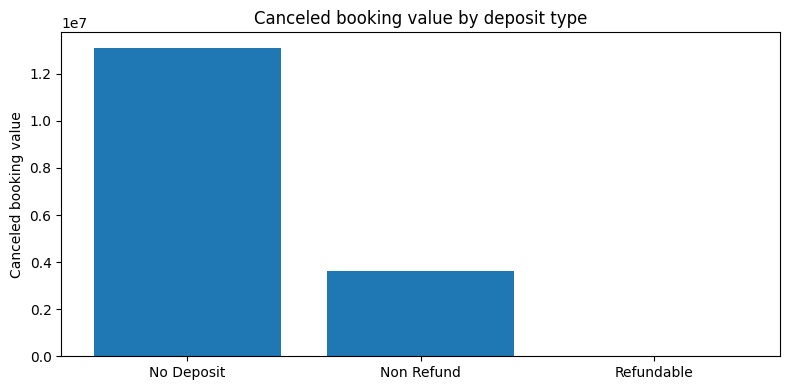

In [31]:
# Денежный масштаб отмен по типу депозита и сегменту.
money_by_deposit = (
    model_df.assign(canceled_value=lambda x: x["booking_value"] * x["is_canceled"])
    .groupby("deposit_type", observed=False)
    .agg(
        bookings=("is_canceled", "size"),
        cancel_rate=("is_canceled", "mean"),
        total_booking_value=("booking_value", "sum"),
        canceled_booking_value=("canceled_value", "sum"),
    )
    .sort_values("canceled_booking_value", ascending=False)
)
display(money_by_deposit.style.format({
    "cancel_rate": "{:.1%}",
    "total_booking_value": "{:,.0f}",
    "canceled_booking_value": "{:,.0f}",
}))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(money_by_deposit.index.astype(str), money_by_deposit["canceled_booking_value"].values)
ax.set_title("Canceled booking value by deposit type")
ax.set_ylabel("Canceled booking value")
save_current_fig("canceled_value_by_deposit_type.png")
plt.show()

### Важный вывод по `Non Refund`

Если сортировать бронирования только по `risk_score`, наверху часто оказываются `Non Refund`: модель видит высокую вероятность отмены. Но для revenue-менеджера это не всегда top-priority, потому что финансовая потеря по невозвратному тарифу ниже. Поэтому дальше вводится `deposit_loss_factor` и отдельный `business_priority_score`.

## 5. Time-based split

Используется хронологический split по дате заезда: ранние бронирования — train, следующий период — validation, последний период — test. Это реалистичнее random split, потому что продукт будет применяться на будущих бронированиях.

,split,rows,date_min,date_max,cancel_rate
0,train,83446,2015-07-01 00:00:00,2017-02-10 00:00:00,36.1%
1,validation,17881,2017-02-10 00:00:00,2017-05-22 00:00:00,39.4%
2,test,17882,2017-05-22 00:00:00,2017-08-31 00:00:00,39.4%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/split_cancel_rate.png


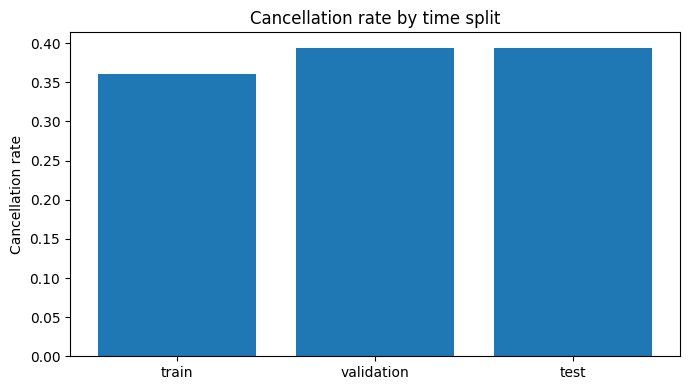

In [32]:
y = model_df["is_canceled"].astype(int)
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

idx_train = np.arange(0, train_end)
idx_val = np.arange(train_end, val_end)
idx_test = np.arange(val_end, n)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(idx_train), len(idx_val), len(idx_test)],
    "date_min": [model_df.iloc[idx_train]["arrival_date"].min(), model_df.iloc[idx_val]["arrival_date"].min(), model_df.iloc[idx_test]["arrival_date"].min()],
    "date_max": [model_df.iloc[idx_train]["arrival_date"].max(), model_df.iloc[idx_val]["arrival_date"].max(), model_df.iloc[idx_test]["arrival_date"].max()],
    "cancel_rate": [y.iloc[idx_train].mean(), y.iloc[idx_val].mean(), y.iloc[idx_test].mean()],
})
display(split_summary.style.format({"cancel_rate": "{:.1%}"}))
split_summary.to_csv(TABLE_DIR / "hw56_split_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_summary["split"], split_summary["cancel_rate"])
ax.set_title("Cancellation rate by time split")
ax.set_ylabel("Cancellation rate")
save_current_fig("split_cancel_rate.png")
plt.show()

## 6. Feature set и preprocessing

Из признаков исключаются leakage-колонки, спорные постфактум-признаки и анонимизированные high-cardinality ID. Это делает результат более консервативным и переносимым на новый отель.

In [33]:
exclude_columns = set(["is_canceled", "arrival_date"])
exclude_columns.update(LEAKAGE_COLUMNS)
exclude_columns.update(CONSERVATIVE_EXCLUDE_COLUMNS)
exclude_columns.update(HIGH_CARDINALITY_OPERATIONAL_IDS)

feature_cols = [c for c in model_df.columns if c not in exclude_columns]

# Важно: pandas может хранить текстовые колонки не только как object/category,
# но и как string/string[python]/string[pyarrow]. Поэтому числовые признаки
# выбираем строго через is_numeric_dtype, а всё нечисловое отправляем в OHE.
num_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(model_df[c])]
non_num_cols = [c for c in feature_cols if c not in num_cols]
cat_tab_cols = [c for c in non_num_cols if c != "booking_text"]

X_train = model_df.iloc[idx_train][feature_cols].copy()
X_val = model_df.iloc[idx_val][feature_cols].copy()
X_test = model_df.iloc[idx_test][feature_cols].copy()
y_train = y.iloc[idx_train].copy()
y_val = y.iloc[idx_val].copy()
y_test = y.iloc[idx_test].copy()

# Защита от тихого попадания строковых колонок в median-imputer.
assert all(pd.api.types.is_numeric_dtype(X_train[c]) for c in num_cols), num_cols
assert "booking_text" not in num_cols
assert not set(num_cols).intersection(cat_tab_cols)

print("feature count:", len(feature_cols))
print("numeric:", len(num_cols), num_cols)
print("categorical:", len(cat_tab_cols), cat_tab_cols)
print("text feature:", "booking_text" in feature_cols)
print("non-numeric not encoded in OHE:", [c for c in non_num_cols if c not in cat_tab_cols and c != "booking_text"])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        min_frequency=20
    ))
])

preprocess_ohe = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_tab_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


feature count: 37
numeric: 24 ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'arrival_month_num', 'total_nights', 'total_guests', 'has_children', 'has_previous_cancellations', 'has_special_requests', 'has_parking_request', 'booking_value']
categorical: 12 ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'lead_time_bin', 'nights_bin', 'adr_bin']
text feature: True
non-numeric not encoded in OHE: []


## 7. Метрики

Используются три уровня оценки:

1. **Классические ML-метрики:** ROC-AUC, PR-AUC, Brier Score, Precision, Recall, F1.
2. **Ranking-first метрики:** Precision@10/20, Recall@10/20, Lift@10/20.
3. **Совокупная метрика `quality_index`:** агрегирует разделяющую способность, качество на положительном классе, top-list и калибровку.

Accuracy намеренно не является основной метрикой: менеджеру нужен не общий процент верных ответов, а качественный top-list бронирований для обработки.

In [34]:
def topk_metrics(y_true, score, frac=0.20):
    y_true = np.asarray(y_true)
    score = np.asarray(score)
    k = max(1, int(np.ceil(len(y_true) * frac)))
    order = np.argsort(score)[::-1][:k]
    precision_k = y_true[order].mean()
    recall_k = y_true[order].sum() / max(1, y_true.sum())
    lift_k = precision_k / max(1e-12, y_true.mean())
    return precision_k, recall_k, lift_k


def select_threshold_by_f2(y_true, score):
    grid = np.quantile(score, np.linspace(0.05, 0.95, 61))
    best_t, best_value = 0.5, -1
    for t in grid:
        pred = (score >= t).astype(int)
        precision, recall, _, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
        f2 = (5 * precision * recall) / (4 * precision + recall) if (precision + recall) else 0
        if f2 > best_value:
            best_t, best_value = float(t), float(f2)
    return best_t


def evaluate_scores(model_name, y_true, score, threshold=0.5, train_time_sec=None, model_type="", best_params=""):
    pred = (score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, pred, average="binary", zero_division=0)
    p10, r10, l10 = topk_metrics(y_true, score, 0.10)
    p20, r20, l20 = topk_metrics(y_true, score, 0.20)
    return {
        "model": model_name,
        "type": model_type,
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "brier": brier_score_loss(y_true, score),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "precision_at_10": p10,
        "recall_at_10": r10,
        "lift_at_10": l10,
        "precision_at_20": p20,
        "recall_at_20": r20,
        "lift_at_20": l20,
        "threshold": threshold,
        "train_time_sec": train_time_sec,
        "best_params": best_params,
    }


def add_quality_index(df_metrics):
    df = df_metrics.copy()
    df["quality_index"] = (
        0.35 * df["roc_auc"] +
        0.25 * df["pr_auc"] +
        0.20 * np.minimum(df["lift_at_20"] / 3, 1) +
        0.10 * df["recall_at_20"] +
        0.10 * (1 - df["brier"])
    )
    return df.sort_values("quality_index", ascending=False).reset_index(drop=True)

results = []
test_scores = {}
validation_scores = {}
trained_models = {}

## 8. Baseline 1: Naive prior

Наивный baseline предсказывает среднюю вероятность отмены на train. Он нужен, чтобы не переоценить сложные модели.

In [35]:
start = time.time()
prior_score_test = np.full(len(y_test), y_train.mean())
prior_score_val = np.full(len(y_val), y_train.mean())
results.append(evaluate_scores(
    "Naive prior",
    y_test,
    prior_score_test,
    threshold=0.5,
    train_time_sec=time.time() - start,
    model_type="naive",
))
test_scores["Naive prior"] = prior_score_test
validation_scores["Naive prior"] = prior_score_val
print("Train cancellation prior:", round(float(y_train.mean()), 4))

Train cancellation prior: 0.3608


## 9. Baseline 2: Rule-based scoring

Эвристический baseline кодирует бизнес-логику: длинный `lead_time`, отсутствие депозита, прошлые отмены, отсутствие спецзапросов, отсутствие parking request и рискованные каналы.

In [36]:
def rule_based_score(X):
    s = np.zeros(len(X), dtype=float)
    s += (X["lead_time"] > 90).astype(float)
    s += (X["deposit_type"].eq("No Deposit")).astype(float)
    s += (X["previous_cancellations"] > 0).astype(float) * 1.3
    s += (X["total_of_special_requests"].eq(0)).astype(float)
    s += (X["required_car_parking_spaces"].eq(0)).astype(float) * 0.5
    s += (X["market_segment"].isin(["Online TA", "Groups", "Offline TA/TO"])).astype(float)
    return s / max(1, s.max())

start = time.time()
score_val = rule_based_score(X_val)
threshold = select_threshold_by_f2(y_val, score_val)
score_test = rule_based_score(X_test)
results.append(evaluate_scores(
    "Rule-based risk score", y_test, score_test, threshold,
    train_time_sec=time.time() - start,
    model_type="heuristic",
))
test_scores["Rule-based risk score"] = score_test
validation_scores["Rule-based risk score"] = score_val
print("Rule-based threshold:", threshold)

Rule-based threshold: 0.5208333333333334


## 10. Simple model 1: Logistic Regression

Логистическая регрессия — сильный табличный baseline. Она простая, интерпретируемая и показывает, насколько далеко можно продвинуться без сложных ансамблей.

In [37]:
start = time.time()
logreg_pipeline = Pipeline([
    ("prep", preprocess_ohe),
    ("clf", LogisticRegression(
        max_iter=700,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1,
        C=1.0,
    )),
])
logreg_pipeline.fit(X_train, y_train)
train_time = time.time() - start

score_val = logreg_pipeline.predict_proba(X_val)[:, 1]
threshold = select_threshold_by_f2(y_val, score_val)
score_test = logreg_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_scores(
    "Logistic Regression", y_test, score_test, threshold,
    train_time_sec=train_time,
    model_type="simple_ml",
))
test_scores["Logistic Regression"] = score_test
validation_scores["Logistic Regression"] = score_val
trained_models["Logistic Regression"] = logreg_pipeline
print("train_time_sec:", round(train_time, 2), "threshold:", round(threshold, 4))

train_time_sec: 0.99 threshold: 0.3364


## 11. Simple model 2: Random Forest

Random Forest добавлен как простая нелинейная модель. Он не является главным кандидатом, но помогает проверить, дают ли нелинейности прирост относительно Logistic Regression.

In [38]:
start = time.time()
rf_pipeline = Pipeline([
    ("prep", preprocess_ohe),
    ("clf", RandomForestClassifier(
        n_estimators=160,
        max_depth=16,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
rf_pipeline.fit(X_train, y_train)
train_time = time.time() - start

score_val = rf_pipeline.predict_proba(X_val)[:, 1]
threshold = select_threshold_by_f2(y_val, score_val)
score_test = rf_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_scores(
    "Random Forest", y_test, score_test, threshold,
    train_time_sec=train_time,
    model_type="simple_ml_nonlinear",
))
test_scores["Random Forest"] = score_test
validation_scores["Random Forest"] = score_val
trained_models["Random Forest"] = rf_pipeline
print("train_time_sec:", round(train_time, 2), "threshold:", round(threshold, 4))

train_time_sec: 1.91 threshold: 0.2643


## 12. Подготовка OHE-матриц для сложных моделей

Для LightGBM и XGBoost используется один общий sparse-препроцессинг. Это ускоряет перебор гиперпараметров и делает сравнение честным.

In [39]:
start = time.time()
Xt_train = preprocess_ohe.fit_transform(X_train, y_train)
Xt_val = preprocess_ohe.transform(X_val)
Xt_test = preprocess_ohe.transform(X_test)
print("OHE shapes:", Xt_train.shape, Xt_val.shape, Xt_test.shape)
print("OHE preparation time:", round(time.time() - start, 2), "sec")

OHE shapes: (83446, 155) (17881, 155) (17882, 155)
OHE preparation time: 0.49 sec


## 13. Complex model 1: LightGBM Random Search

LightGBM — основной кандидат для табличных данных. Здесь используется Random Search по гиперпараметрам, то есть AutoML-like перебор внутри выбранного семейства моделей.

In [40]:
if RUN_LONG_EXPERIMENTS:
    try:
        from lightgbm import LGBMClassifier

        param_dist_lgbm = {
            "num_leaves": randint(24, 128),
            "max_depth": randint(4, 12),
            "learning_rate": loguniform(0.02, 0.15),
            "n_estimators": randint(250, 650),
            "min_child_samples": randint(20, 160),
            "subsample": uniform(0.70, 0.30),
            "colsample_bytree": uniform(0.70, 0.30),
            "reg_lambda": loguniform(1e-3, 15),
        }

        best_lgbm = None
        start_total = time.time()
        for i, params in enumerate(ParameterSampler(param_dist_lgbm, n_iter=N_ITER_LGBM, random_state=RANDOM_STATE)):
            model = LGBMClassifier(
                objective="binary",
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=4,
                verbosity=-1,
                **params,
            )
            model.fit(Xt_train, y_train)
            score_val = model.predict_proba(Xt_val)[:, 1]
            val_auc = roc_auc_score(y_val, score_val)
            print(f"LGBM iteration {i}: val ROC-AUC={val_auc:.4f}")
            if best_lgbm is None or val_auc > best_lgbm["val_auc"]:
                best_lgbm = {"val_auc": val_auc, "model": model, "params": params}

        train_time = time.time() - start_total
        score_val = best_lgbm["model"].predict_proba(Xt_val)[:, 1]
        threshold = select_threshold_by_f2(y_val, score_val)
        score_test = best_lgbm["model"].predict_proba(Xt_test)[:, 1]

        results.append(evaluate_scores(
            "LightGBM random search", y_test, score_test, threshold,
            train_time_sec=train_time,
            model_type="complex_hpo_automl_like",
            best_params=str(best_lgbm["params"]),
        ))
        test_scores["LightGBM random search"] = score_test
        validation_scores["LightGBM random search"] = score_val
        trained_models["LightGBM random search"] = best_lgbm["model"]
        print("Best LightGBM params:", best_lgbm["params"])
    except Exception as e:
        print("LightGBM block skipped because of error:", repr(e))
else:
    print("RUN_LONG_EXPERIMENTS=False: LightGBM search skipped")

LGBM iteration 0: val ROC-AUC=0.8997
LGBM iteration 1: val ROC-AUC=0.9019
LGBM iteration 2: val ROC-AUC=0.9001
LGBM iteration 3: val ROC-AUC=0.9002
LGBM iteration 4: val ROC-AUC=0.9030
LGBM iteration 5: val ROC-AUC=0.9033
LGBM iteration 6: val ROC-AUC=0.8971
LGBM iteration 7: val ROC-AUC=0.9035
Best LightGBM params: {'colsample_bytree': np.float64(0.7935133228268232), 'learning_rate': np.float64(0.057032364235875585), 'max_depth': 5, 'min_child_samples': 23, 'n_estimators': 559, 'num_leaves': 116, 'reg_lambda': np.float64(11.196283558285792), 'subsample': np.float64(0.9325398470083344)}


## 14. Complex model 2: XGBoost Random Search

XGBoost — второе независимое семейство градиентного бустинга. Оно добавлено не как декоративная модель, а как реальная проверка: если LightGBM выигрывает, это должно быть видно в leaderboard; если XGBoost выигрывает, финальный выбор должен измениться.

In [41]:
if RUN_LONG_EXPERIMENTS:
    try:
        from xgboost import XGBClassifier

        scale_pos_weight = (len(y_train) - y_train.sum()) / max(1, y_train.sum())
        param_dist_xgb = {
            "max_depth": randint(3, 8),
            "learning_rate": loguniform(0.02, 0.18),
            "n_estimators": randint(200, 450),
            "subsample": uniform(0.70, 0.30),
            "colsample_bytree": uniform(0.70, 0.30),
            "min_child_weight": loguniform(1, 20),
            "reg_lambda": loguniform(1e-3, 15),
        }

        best_xgb = None
        start_total = time.time()
        for i, params in enumerate(ParameterSampler(param_dist_xgb, n_iter=N_ITER_XGB, random_state=44)):
            model = XGBClassifier(
                objective="binary:logistic",
                tree_method="hist",
                eval_metric="auc",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                scale_pos_weight=scale_pos_weight,
                **params,
            )
            model.fit(Xt_train, y_train, eval_set=[(Xt_val, y_val)], verbose=False)
            score_val = model.predict_proba(Xt_val)[:, 1]
            val_auc = roc_auc_score(y_val, score_val)
            print(f"XGBoost iteration {i}: val ROC-AUC={val_auc:.4f}")
            if best_xgb is None or val_auc > best_xgb["val_auc"]:
                best_xgb = {"val_auc": val_auc, "model": model, "params": params}

        train_time = time.time() - start_total
        score_val = best_xgb["model"].predict_proba(Xt_val)[:, 1]
        threshold = select_threshold_by_f2(y_val, score_val)
        score_test = best_xgb["model"].predict_proba(Xt_test)[:, 1]

        results.append(evaluate_scores(
            "XGBoost random search", y_test, score_test, threshold,
            train_time_sec=train_time,
            model_type="complex_hpo",
            best_params=str(best_xgb["params"]),
        ))
        test_scores["XGBoost random search"] = score_test
        validation_scores["XGBoost random search"] = score_val
        trained_models["XGBoost random search"] = best_xgb["model"]
        print("Best XGBoost params:", best_xgb["params"])
    except Exception as e:
        print("XGBoost block skipped because of error:", repr(e))
else:
    print("RUN_LONG_EXPERIMENTS=False: XGBoost search skipped")

XGBoost iteration 0: val ROC-AUC=0.9008
XGBoost iteration 1: val ROC-AUC=0.9020
XGBoost iteration 2: val ROC-AUC=0.8932
XGBoost iteration 3: val ROC-AUC=0.8931
XGBoost iteration 4: val ROC-AUC=0.9009
XGBoost iteration 5: val ROC-AUC=0.8920
Best XGBoost params: {'colsample_bytree': np.float64(0.8181338653264754), 'learning_rate': np.float64(0.049134265635794296), 'max_depth': 6, 'min_child_weight': np.float64(15.589760830378902), 'n_estimators': 427, 'reg_lambda': np.float64(10.262311031520227), 'subsample': np.float64(0.8369863326816811)}


## 15. Complex model 3: Tabular + serialized text TF-IDF

Этот блок реализует идею из лекции про табличные + текстовые данные: часть табличных полей сериализуется в текстовое описание бронирования, затем объединяется с обычными табличными признаками. Это не обязательно должно победить бустинг, но это отдельная модельная гипотеза: текстовая сериализация может ловить сочетания категорий и короткие шаблоны.

In [42]:
if RUN_LONG_EXPERIMENTS:
    try:
        text_tabular_preprocess = ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30)),
            ]), cat_tab_cols),
            ("text", TfidfVectorizer(
                min_df=5,
                ngram_range=(1, 2),
                max_features=12_000,
            ), "booking_text"),
        ])

        alpha_grid = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3][:N_ITER_MULTIMODAL]
        best_mm = None
        start_total = time.time()
        for alpha in alpha_grid:
            model = Pipeline([
                ("features", text_tabular_preprocess),
                ("clf", SGDClassifier(
                    loss="log_loss",
                    class_weight="balanced",
                    alpha=alpha,
                    max_iter=2000,
                    tol=1e-4,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                )),
            ])
            model.fit(X_train, y_train)
            score_val = model.predict_proba(X_val)[:, 1]
            val_auc = roc_auc_score(y_val, score_val)
            print(f"Multimodal alpha={alpha}: val ROC-AUC={val_auc:.4f}")
            if best_mm is None or val_auc > best_mm["val_auc"]:
                best_mm = {"val_auc": val_auc, "model": model, "alpha": alpha}

        train_time = time.time() - start_total
        score_val = best_mm["model"].predict_proba(X_val)[:, 1]
        threshold = select_threshold_by_f2(y_val, score_val)
        score_test = best_mm["model"].predict_proba(X_test)[:, 1]

        results.append(evaluate_scores(
            "Tabular + serialized text TF-IDF", y_test, score_test, threshold,
            train_time_sec=train_time,
            model_type="complex_multimodal_serialization",
            best_params=f"alpha={best_mm['alpha']}",
        ))
        test_scores["Tabular + serialized text TF-IDF"] = score_test
        validation_scores["Tabular + serialized text TF-IDF"] = score_val
        trained_models["Tabular + serialized text TF-IDF"] = best_mm["model"]
        print("Best multimodal alpha:", best_mm["alpha"])
    except Exception as e:
        print("Multimodal block skipped because of error:", repr(e))
else:
    print("RUN_LONG_EXPERIMENTS=False: multimodal search skipped")

Multimodal alpha=1e-05: val ROC-AUC=0.8854
Multimodal alpha=3e-05: val ROC-AUC=0.8852
Multimodal alpha=0.0001: val ROC-AUC=0.8829
Multimodal alpha=0.0003: val ROC-AUC=0.8839
Multimodal alpha=0.001: val ROC-AUC=0.8855
Best multimodal alpha: 0.001


## 16. Leaderboard и выбор модели

Финальный выбор делается не по одной метрике. Для продукта важны одновременно:

- способность ранжировать отмены (`ROC-AUC`, `PR-AUC`),
- качество верхнего списка (`Precision@20`, `Lift@20`),
- полнота верхнего списка (`Recall@20`),
- калибровка вероятностей (`Brier`).

In [43]:
leaderboard = add_quality_index(pd.DataFrame(results))
metric_cols = [
    "model", "type", "quality_index", "roc_auc", "pr_auc", "brier",
    "precision", "recall", "f1",
    "precision_at_20", "recall_at_20", "lift_at_20",
    "threshold", "train_time_sec", "best_params",
]
leaderboard = leaderboard[metric_cols]
display(leaderboard.style.format({
    "quality_index": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "brier": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "precision_at_20": "{:.4f}",
    "recall_at_20": "{:.4f}",
    "lift_at_20": "{:.4f}",
    "threshold": "{:.4f}",
    "train_time_sec": "{:.1f}",
}))
leaderboard.to_csv(TABLE_DIR / "hw56_advanced_model_leaderboard.csv", index=False)

best_model_name = leaderboard.iloc[0]["model"]
print("Best model by quality_index:", best_model_name)

,model,type,quality_index,roc_auc,pr_auc,brier,precision,recall,f1,precision_at_20,recall_at_20,lift_at_20,threshold,train_time_sec,best_params
0,LightGBM random search,complex_hpo_automl_like,0.7607,0.8530,0.7942,0.1607,0.5326,0.9756,0.6891,0.8172,0.4147,2.0730,0.2099,12.9,"{'colsample_bytree': np.float64(0.7935133228268232), 'learning_rate': np.float64(0.057032364235875585), 'max_depth': 5, 'min_child_samples': 23, 'n_estimators': 559, 'num_leaves': 116, 'reg_lambda': np.float64(11.196283558285792), 'subsample': np.float64(0.9325398470083344)}"
1,XGBoost random search,complex_hpo,0.7588,0.8501,0.7912,0.1611,0.5383,0.9660,0.6913,0.8166,0.4144,2.0716,0.2252,12.5,"{'colsample_bytree': np.float64(0.8181338653264754), 'learning_rate': np.float64(0.049134265635794296), 'max_depth': 6, 'min_child_weight': np.float64(15.589760830378902), 'n_estimators': 427, 'reg_lambda': np.float64(10.262311031520227), 'subsample': np.float64(0.8369863326816811)}"
2,Tabular + serialized text TF-IDF,complex_multimodal_serialization,0.7488,0.8371,0.7807,0.1878,0.5142,0.9706,0.6723,0.8160,0.4141,2.0702,0.3348,12.6,alpha=0.001
3,Random Forest,simple_ml_nonlinear,0.7457,0.8372,0.7752,0.1631,0.5298,0.9705,0.6854,0.7968,0.4043,2.0212,0.2643,1.9,
4,Logistic Regression,simple_ml,0.7445,0.8340,0.7766,0.1927,0.5161,0.9682,0.6733,0.8082,0.4101,2.0503,0.3364,1.0,
5,Rule-based risk score,heuristic,0.5199,0.6231,0.4732,0.3217,0.4154,0.9888,0.5850,0.5261,0.2670,1.3347,0.5208,0.1,
6,Naive prior,naive,0.4376,0.5000,0.3942,0.2399,0.0000,0.0000,0.0000,0.4003,0.2031,1.0156,0.5000,0.0,


Best model by quality_index: LightGBM random search


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/model_leaderboard_quality_index.png


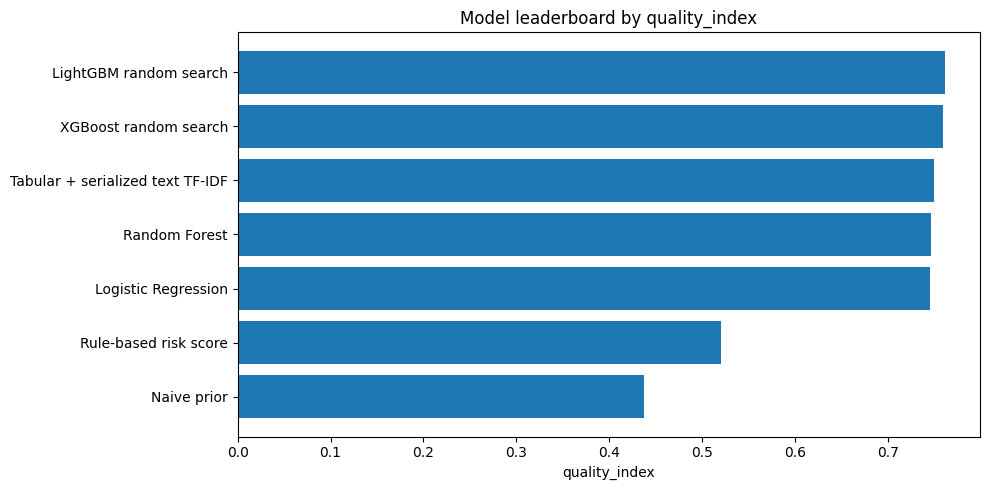

saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/model_lift_at_20.png


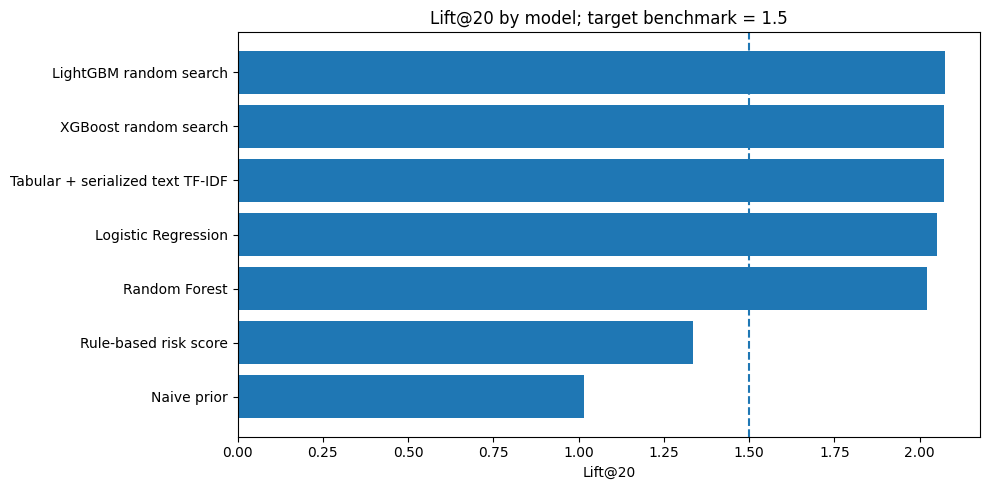

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = leaderboard.sort_values("quality_index", ascending=True)
ax.barh(plot_df["model"], plot_df["quality_index"])
ax.set_title("Model leaderboard by quality_index")
ax.set_xlabel("quality_index")
save_current_fig("model_leaderboard_quality_index.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = leaderboard.sort_values("lift_at_20", ascending=True)
ax.barh(plot_df["model"], plot_df["lift_at_20"])
ax.axvline(1.5, linestyle="--")
ax.set_title("Lift@20 by model; target benchmark = 1.5")
ax.set_xlabel("Lift@20")
save_current_fig("model_lift_at_20.png")
plt.show()

## 17. ROC и Precision-Recall curves

Эти графики показывают не только итоговую цифру, но и форму trade-off. PR curve особенно важна, потому что положительный класс — отмена бронирования.

saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/roc_curves.png


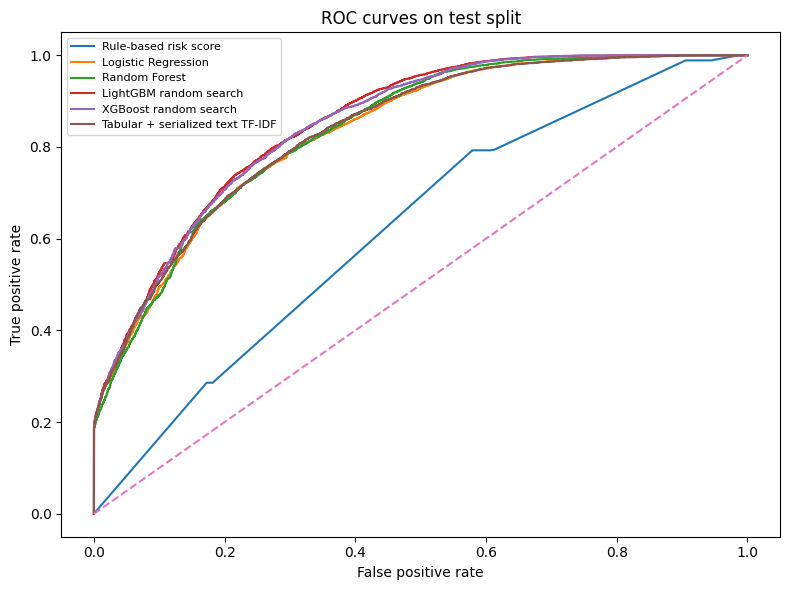

saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/precision_recall_curves.png


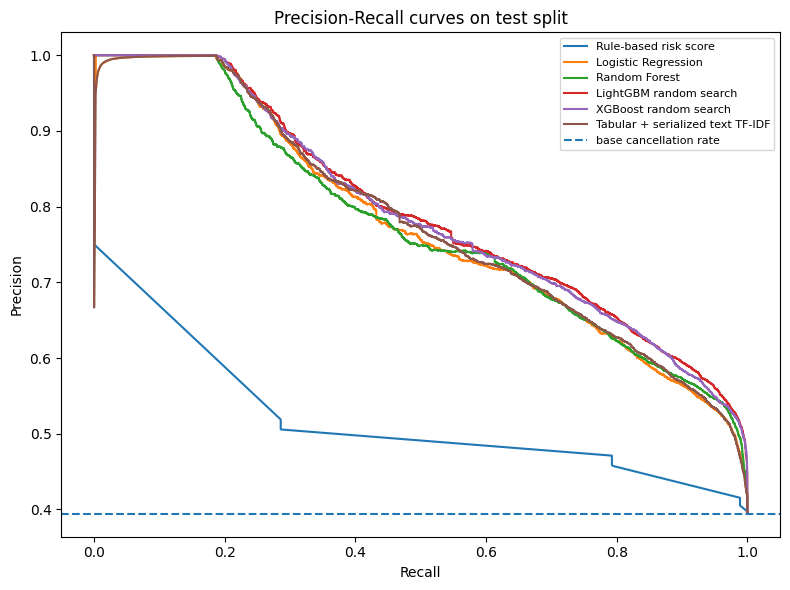

In [45]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, score in test_scores.items():
    if len(np.unique(score)) > 1:
        fpr, tpr, _ = roc_curve(y_test, score)
        ax.plot(fpr, tpr, label=name)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curves on test split")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(fontsize=8)
save_current_fig("roc_curves.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
for name, score in test_scores.items():
    if len(np.unique(score)) > 1:
        precision, recall, _ = precision_recall_curve(y_test, score)
        ax.plot(recall, precision, label=name)
ax.axhline(y_test.mean(), linestyle="--", label="base cancellation rate")
ax.set_title("Precision-Recall curves on test split")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=8)
save_current_fig("precision_recall_curves.png")
plt.show()

## 18. Исправленная бизнес-логика: risk score ≠ financial loss

Теперь `Non Refund` не попадает автоматически в самый высокий финансовый приоритет. Вводится коэффициент ожидаемой потери по типу депозита:

| deposit_type | deposit_loss_factor | Логика |
|---|---:|---|
| No Deposit | 1.00 | отель слабо защищен, потеря ближе к полной стоимости брони |
| Refundable | 0.80 | часть риска сохраняется из-за гибких условий |
| Non Refund | 0.05 | риск отмены может быть высоким, но выручка в значительной степени защищена |

Коэффициенты можно калибровать на реальных договорах отеля, но уже в учебном прототипе важно не смешивать вероятность отмены и денежную потерю.

In [46]:
def deposit_loss_factor(deposit_type):
    mapping = {
        "No Deposit": 1.00,
        "Refundable": 0.80,
        "Non Refund": 0.05,
    }
    return mapping.get(deposit_type, 1.00)


def assign_risk_category(score):
    if score >= 0.80:
        return "Critical"
    if score >= 0.60:
        return "High"
    if score >= 0.30:
        return "Medium"
    return "Low"


def recommended_action(row):
    if row["deposit_type"] == "Non Refund":
        return "низкий финансовый приоритет; проверить оплату/условия удержания; учитывать в прогнозе загрузки"
    if row["risk_category"] in ["Critical", "High"] and row["deposit_type"] == "No Deposit":
        return "высокий приоритет: запросить подтверждение, предложить депозит/невозвратный тариф, учесть в overbooking"
    if row["risk_category"] in ["Critical", "High"] and row["deposit_type"] == "Refundable":
        return "средний/высокий приоритет: напоминание, уточнение намерения приехать, контроль срока бесплатной отмены"
    if row["risk_category"] == "Medium":
        return "мягкое напоминание или мониторинг без ручной эскалации"
    return "без дополнительных действий"

best_scores = test_scores[best_model_name]
business_df = model_df.iloc[idx_test].copy()
business_df["booking_id"] = business_df.index + 1
business_df["risk_score"] = best_scores
business_df["risk_category"] = business_df["risk_score"].apply(assign_risk_category)
business_df["deposit_loss_factor"] = business_df["deposit_type"].apply(deposit_loss_factor)
business_df["expected_loss"] = business_df["risk_score"] * business_df["booking_value"] * business_df["deposit_loss_factor"]
business_df["business_priority_score"] = business_df["expected_loss"]
business_df["why_risky"] = np.select(
    [
        business_df["total_of_special_requests"].eq(0) & business_df["required_car_parking_spaces"].eq(0),
        business_df["lead_time"].gt(90),
        business_df["previous_cancellations"].gt(0),
    ],
    [
        "нет спецзапросов и parking request",
        "длинный lead_time",
        "есть предыдущие отмены",
    ],
    default="комбинация факторов модели",
)
business_df["recommended_action"] = business_df.apply(recommended_action, axis=1)

manager_columns = [
    "booking_id", "hotel", "arrival_date_month", "lead_time", "market_segment", "deposit_type",
    "booking_value", "risk_score", "risk_category", "deposit_loss_factor", "expected_loss",
    "business_priority_score", "why_risky", "recommended_action", "is_canceled",
]

top_by_risk = business_df[manager_columns].sort_values("risk_score", ascending=False).head(20)
top_by_business = business_df[manager_columns].sort_values("business_priority_score", ascending=False).head(20)

print("Top-20 by raw ML risk_score:")
display(top_by_risk)
print("Top-20 by corrected business_priority_score:")
display(top_by_business)

top_by_business.to_csv(TABLE_DIR / "hw56_top_business_priority_bookings.csv", index=False)

Top-20 by raw ML risk_score:


,booking_id,hotel,arrival_date_month,lead_time,market_segment,deposit_type,booking_value,risk_score,risk_category,deposit_loss_factor,expected_loss,business_priority_score,why_risky,recommended_action,is_canceled
103847,103848,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103860,103861,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103848,103849,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103850,103851,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103851,103852,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103852,103853,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103855,103856,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103858,103859,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103859,103860,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1
103861,103862,Resort Hotel,June,323,Groups,Non Refund,504.0,0.999835,Critical,0.05,25.19585,25.19585,нет спецзапросов и parking request,низкий финансовый приоритет; проверить оплату/...,1


Top-20 by corrected business_priority_score:


,booking_id,hotel,arrival_date_month,lead_time,market_segment,deposit_type,booking_value,risk_score,risk_category,deposit_loss_factor,expected_loss,business_priority_score,why_risky,recommended_action,is_canceled
114313,114314,Resort Hotel,August,378,Online TA,No Deposit,6300.00,0.968836,Critical,1.0,6103.664301,6103.664301,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
115437,115438,Resort Hotel,August,328,Online TA,No Deposit,4088.00,0.860670,Critical,1.0,3518.417240,3518.417240,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
117504,117505,Resort Hotel,August,83,Online TA,No Deposit,3890.06,0.847263,Critical,1.0,3295.903255,3295.903255,комбинация факторов модели,"высокий приоритет: запросить подтверждение, пр...",1
115951,115952,Resort Hotel,August,238,Online TA,No Deposit,3865.94,0.847608,Critical,1.0,3276.803118,3276.803118,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
109457,109458,Resort Hotel,July,277,Online TA,No Deposit,3638.04,0.840604,Critical,1.0,3058.152398,3058.152398,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
112746,112747,Resort Hotel,July,352,Online TA,No Deposit,3066.00,0.958308,Critical,1.0,2938.173749,2938.173749,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
115648,115649,Resort Hotel,August,116,Direct,No Deposit,3920.00,0.745505,High,1.0,2922.378127,2922.378127,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
115211,115212,Resort Hotel,August,45,Online TA,No Deposit,3024.00,0.911850,Critical,1.0,2757.434570,2757.434570,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
111892,111893,Resort Hotel,July,236,Online TA,No Deposit,2926.72,0.939145,Critical,1.0,2748.614811,2748.614811,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1
118772,118773,Resort Hotel,August,237,Online TA,No Deposit,2936.00,0.926682,Critical,1.0,2720.738716,2720.738716,нет спецзапросов и parking request,"высокий приоритет: запросить подтверждение, пр...",1


,sorting,non_refund_share,no_deposit_share,expected_loss_sum
0,top by risk_score,100.0%,0.0%,504
1,top by business_priority_score,0.0%,100.0%,"58,429"


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/risk_vs_business_priority_expected_loss.png


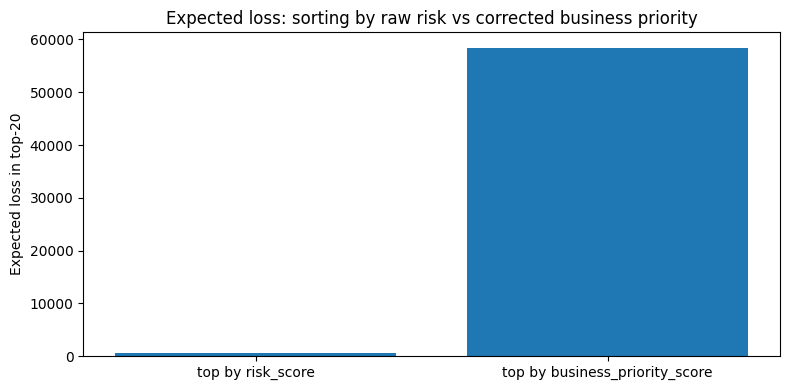

saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/risk_score_vs_expected_loss.png


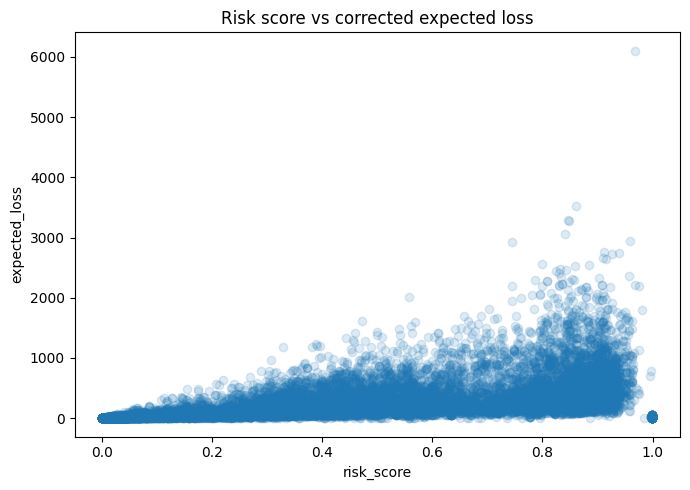

In [47]:
compare_priority = pd.DataFrame({
    "sorting": ["top by risk_score", "top by business_priority_score"],
    "non_refund_share": [
        (top_by_risk["deposit_type"] == "Non Refund").mean(),
        (top_by_business["deposit_type"] == "Non Refund").mean(),
    ],
    "no_deposit_share": [
        (top_by_risk["deposit_type"] == "No Deposit").mean(),
        (top_by_business["deposit_type"] == "No Deposit").mean(),
    ],
    "expected_loss_sum": [
        top_by_risk["expected_loss"].sum(),
        top_by_business["expected_loss"].sum(),
    ],
})
display(compare_priority.style.format({
    "non_refund_share": "{:.1%}",
    "no_deposit_share": "{:.1%}",
    "expected_loss_sum": "{:,.0f}",
}))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(compare_priority["sorting"], compare_priority["expected_loss_sum"])
ax.set_title("Expected loss: sorting by raw risk vs corrected business priority")
ax.set_ylabel("Expected loss in top-20")
save_current_fig("risk_vs_business_priority_expected_loss.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(business_df["risk_score"], business_df["expected_loss"], alpha=0.15)
ax.set_title("Risk score vs corrected expected loss")
ax.set_xlabel("risk_score")
ax.set_ylabel("expected_loss")
save_current_fig("risk_score_vs_expected_loss.png")
plt.show()

## 19. Business simulation

Финансовая симуляция оценивает не “сколько модель угадала”, а потенциальный эффект от обработки top-risk / top-priority списка. Это ближе к продуктовой логике revenue-менеджера.

,top_frac,selected_bookings,expected_loss,intervention_success_rate,intervention_cost,expected_protected_revenue,net_effect,non_refund_share,no_deposit_share
0,5%,895,"1,149,678",15%,"1,790","172,452","170,662",0.0%,100.0%
1,10%,1789,"1,811,303",15%,"3,578","271,695","268,117",0.0%,99.7%
2,20%,3577,"2,687,454",15%,"7,154","403,118","395,964",0.0%,99.8%
3,30%,5365,"3,274,172",15%,"10,730","491,126","480,396",0.0%,99.9%


saved: /Users/anasteishavolkovski/DVC/Hotel_Booking_Cancellation_Risk/reports/figures/hw56_advanced/business_simulation_net_effect.png


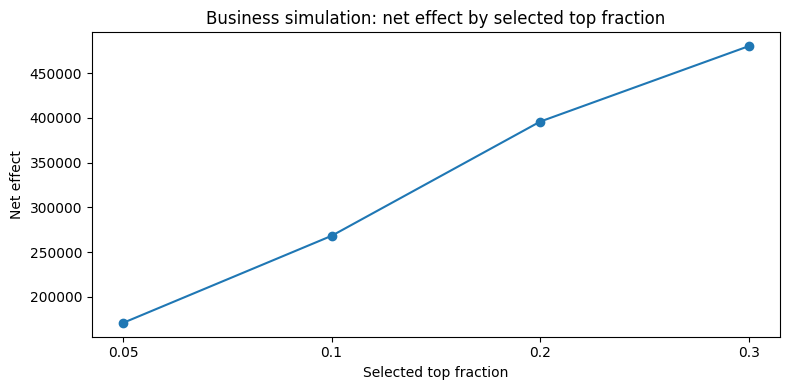

In [48]:
def business_simulation(df, top_frac=0.20, intervention_success_rate=0.15, cost_per_action=2.0):
    k = max(1, int(np.ceil(len(df) * top_frac)))
    selected = df.sort_values("business_priority_score", ascending=False).head(k)
    expected_loss = selected["expected_loss"].sum()
    intervention_cost = cost_per_action * len(selected)
    expected_protected_revenue = expected_loss * intervention_success_rate
    net_effect = expected_protected_revenue - intervention_cost
    return {
        "top_frac": top_frac,
        "selected_bookings": len(selected),
        "expected_loss": expected_loss,
        "intervention_success_rate": intervention_success_rate,
        "intervention_cost": intervention_cost,
        "expected_protected_revenue": expected_protected_revenue,
        "net_effect": net_effect,
        "non_refund_share": (selected["deposit_type"] == "Non Refund").mean(),
        "no_deposit_share": (selected["deposit_type"] == "No Deposit").mean(),
    }

sim_rows = []
for top_frac in [0.05, 0.10, 0.20, 0.30]:
    sim_rows.append(business_simulation(business_df, top_frac=top_frac, intervention_success_rate=0.15, cost_per_action=2.0))
simulation_df = pd.DataFrame(sim_rows)
display(simulation_df.style.format({
    "top_frac": "{:.0%}",
    "expected_loss": "{:,.0f}",
    "intervention_success_rate": "{:.0%}",
    "intervention_cost": "{:,.0f}",
    "expected_protected_revenue": "{:,.0f}",
    "net_effect": "{:,.0f}",
    "non_refund_share": "{:.1%}",
    "no_deposit_share": "{:.1%}",
}))
simulation_df.to_csv(TABLE_DIR / "hw56_business_simulation.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(simulation_df["top_frac"].astype(str), simulation_df["net_effect"], marker="o")
ax.set_title("Business simulation: net effect by selected top fraction")
ax.set_xlabel("Selected top fraction")
ax.set_ylabel("Net effect")
save_current_fig("business_simulation_net_effect.png")
plt.show()

## 20. Segment stability check

Проверяем, не выигрывает ли модель только на одном типе отеля. Это важно, потому что City Hotel и Resort Hotel имеют разные паттерны отмен.

In [49]:
segment_rows = []
for hotel_name, part in business_df.groupby("hotel"):
    idx = part.index
    y_part = part["is_canceled"].astype(int)
    s_part = part["risk_score"]
    p20, r20, l20 = topk_metrics(y_part, s_part, 0.20)
    segment_rows.append({
        "hotel": hotel_name,
        "rows": len(part),
        "cancel_rate": y_part.mean(),
        "roc_auc": roc_auc_score(y_part, s_part) if y_part.nunique() > 1 else np.nan,
        "pr_auc": average_precision_score(y_part, s_part) if y_part.nunique() > 1 else np.nan,
        "precision_at_20": p20,
        "recall_at_20": r20,
        "lift_at_20": l20,
        "expected_loss": part["expected_loss"].sum(),
    })
segment_df = pd.DataFrame(segment_rows)
display(segment_df.style.format({
    "cancel_rate": "{:.1%}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}",
    "precision_at_20": "{:.4f}",
    "recall_at_20": "{:.4f}",
    "lift_at_20": "{:.4f}",
    "expected_loss": "{:,.0f}",
}))
segment_df.to_csv(TABLE_DIR / "hw56_segment_stability_by_hotel.csv", index=False)

,hotel,rows,cancel_rate,roc_auc,pr_auc,precision_at_20,recall_at_20,lift_at_20,expected_loss
0,City Hotel,12010,40.5%,0.8465,0.8041,0.8451,0.4178,2.0889,"2,299,513"
1,Resort Hotel,5872,37.3%,0.8774,0.7876,0.8196,0.4397,2.1975,"2,025,737"


## 21. Итоговый вывод

Финальная модель выбирается по таблице `leaderboard`, отсортированной по интегральному показателю `quality_index`. После полного запуска baseline-моделей и моделей с подбором гиперпараметров лучшей моделью стала **LightGBM random search**.

В контрольном прогоне модель показала следующие метрики:

```text
quality_index ≈ 0.761
ROC-AUC ≈ 0.853
PR-AUC ≈ 0.794
Precision@20 ≈ 0.817
Recall@20 ≈ 0.415
Lift@20 ≈ 2.073
```

Это выше целевого бизнес-бенчмарка `Lift@20 ≥ 1.5`. Значит, верхние 20% броней, отобранные моделью, содержат примерно в 2 раза больше отмен, чем случайная выборка того же размера.

Важные выводы по результатам:

1. **Лучшая ML-модель** — `LightGBM random search`, первая строка `leaderboard` по `quality_index`.
2. **Главные продуктовые метрики** — `Lift@20` и `Precision@20`, потому что revenue-менеджер работает не со всеми бронями, а с ограниченным верхним списком наиболее рискованных кейсов.
3. **Классические ML-метрики** (`ROC-AUC`, `PR-AUC`, `F1`) полезны для сравнения моделей, но сами по себе не отвечают на бизнес-вопрос: какие брони нужно обработать в первую очередь.
4. **Главная бизнес-правка** — сортировать список не только по `risk_score`, а по `business_priority_score`, который учитывает вероятность отмены, стоимость брони и возможную финансовую потерю.
5. **`Non Refund` не должен автоматически попадать в top-priority**: высокая вероятность отмены не всегда означает высокую финансовую потерю для отеля.
6. **Рекомендованная модель для прототипа** — `LightGBM random search`, так как она имеет лучший `quality_index`, проходит целевой порог по `Lift@20` и превосходит rule-based baseline.

Финальная логика решения разделяется на три уровня:

```text
ML layer: P(cancel) = risk_score

Business layer:
expected_loss = risk_score × booking_value × deposit_loss_factor

Manager layer:
sort by business_priority_score + recommended_action
```

Таким образом, итоговое решение не ограничивается построением модели с высокой ML-метрикой. Модель используется как часть бизнес-процесса: она оценивает риск отмены, затем этот риск переводится в ожидаемую финансовую потерю, а на выходе revenue-менеджер получает приоритизированный список броней и рекомендуемое действие.
